# IMPORT LIBRARY

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# LOAD DATASET

In [2]:
import pandas as pd
df = pd.read_excel("Market_basket.xlsx")
df

,Member_number,Date,itemDescription,Transaction_ID,Month,Day_Name
0,1808,2015-07-21,tropical fruit,1808_2015-07-21,July,Tuesday
1,2552,2015-01-05,whole milk,2552_2015-01-05,January,Monday
2,2300,2015-09-19,pip fruit,2300_2015-09-19,September,Saturday
3,1187,2015-12-12,other vegetables,1187_2015-12-12,December,Saturday
4,3037,2015-02-01,whole milk,3037_2015-02-01,February,Sunday
...,...,...,...,...,...,...
38760,4471,2014-10-08,sliced cheese,4471_2014-10-08,October,Wednesday
38761,2022,2014-02-23,candy,2022_2014-02-23,February,Sunday
38762,1097,2014-04-16,cake bar,1097_2014-04-16,April,Wednesday
38763,1510,2014-12-03,fruit/vegetable juice,1510_2014-12-03,December,Wednesday


# DATASET OVERVIEW

In [4]:
# Cek kolom dan baris
df.shape

(38765, 6)

In [5]:
# Cek missing value & tipe data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Member_number    38765 non-null  int64         
 1   Date             38765 non-null  datetime64[ns]
 2   itemDescription  38765 non-null  object        
 3   Transaction_ID   38765 non-null  object        
 4   Month            38765 non-null  object        
 5   Day_Name         38765 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 1.8+ MB


In [7]:
# Cek deskripsi data
df.describe(include="all")

,Member_number,Date,itemDescription,Transaction_ID,Month,Day_Name
count,38765.000000,38765,38765,38765,38765,38765
unique,NaN,NaN,167,14963,12,7
top,NaN,NaN,whole milk,1780_2015-07-12,August,Thursday
freq,NaN,NaN,2502,11,3496,5620
mean,3003.641868,2015-01-09 18:17:12.498387712,NaN,NaN,NaN,NaN
min,1000.000000,2014-01-01 00:00:00,NaN,NaN,NaN,NaN
25%,2002.000000,2014-07-12 00:00:00,NaN,NaN,NaN,NaN
50%,3005.000000,2015-01-21 00:00:00,NaN,NaN,NaN,NaN
75%,4007.000000,2015-07-10 00:00:00,NaN,NaN,NaN,NaN
max,5000.000000,2015-12-30 00:00:00,NaN,NaN,NaN,NaN


# MENGECEK DATA UNIK

In [9]:
# Jumlah pelanggan unik
df['Member_number'].nunique()

3898

In [12]:
# Total produk unik
df['itemDescription'].nunique()

167

In [13]:
# Total transaksi
df['Transaction_ID'].nunique()

14963

In [21]:
# Avarage basket size
basket = (
    df.groupby("Transaction_ID")["itemDescription"]
      .apply(list)
      .reset_index()
)

In [22]:
basket.head()

,Transaction_ID,itemDescription
0,1000_2014-06-24,"[whole milk, pastry, salty snack]"
1,1000_2015-03-15,"[sausage, whole milk, semi-finished bread, yog..."
2,1000_2015-05-27,"[soda, pickled vegetables]"
3,1000_2015-07-24,"[canned beer, misc. beverages]"
4,1000_2015-11-25,"[sausage, hygiene articles]"


In [23]:
basket_size = (
    df.groupby("Transaction_ID")
      .size()
      .reset_index(name="Basket_Size")
)

df = df.merge(basket_size, on="Transaction_ID", how="left")

# DISTRIBUSI PRODUK

In [15]:
top_products = (
    df['itemDescription']
    .value_counts()
    .head(20)
)

top_products

itemDescription
whole milk            2502
other vegetables      1898
rolls/buns            1716
soda                  1514
yogurt                1334
root vegetables       1071
tropical fruit        1032
bottled water          933
sausage                924
citrus fruit           812
pastry                 785
pip fruit              744
shopping bags          731
canned beer            717
bottled beer           687
whipped/sour cream     662
newspapers             596
frankfurter            580
brown bread            571
pork                   566
Name: count, dtype: int64

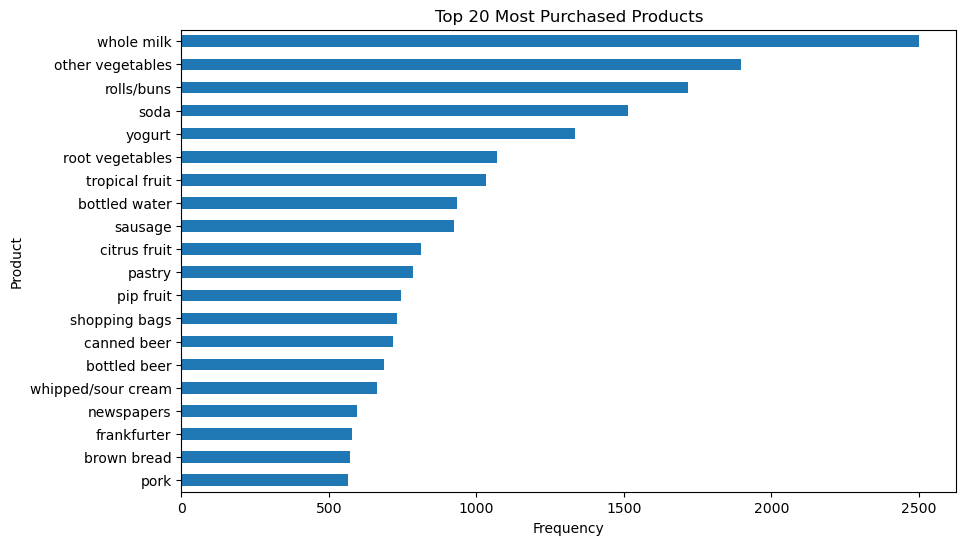

In [16]:
plt.figure(figsize=(10,6))

top_products.sort_values().plot(kind='barh')

plt.title('Top 20 Most Purchased Products')
plt.xlabel('Frequency')
plt.ylabel('Product')

plt.show()

# BASKET SIZE ANALYSIS

In [24]:
basket_size.describe()

,Basket_Size
count,14963.000000
mean,2.590724
std,1.117469
min,2.000000
25%,2.000000
50%,2.000000
75%,3.000000
max,11.000000


In [27]:
basket_size["Basket_Size"].mean()

np.float64(2.590723785337165)

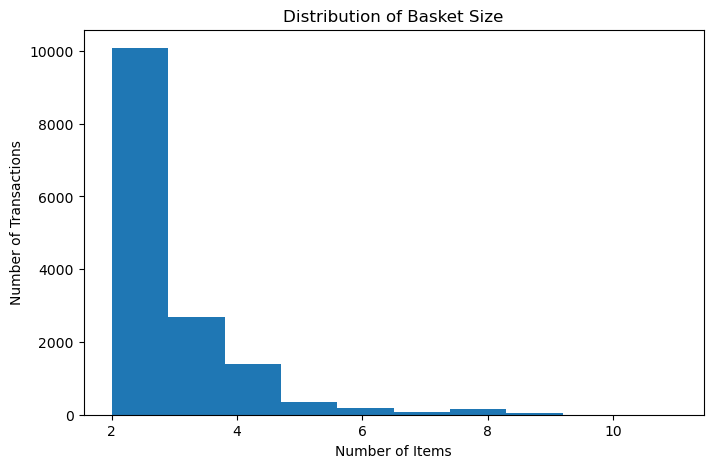

In [28]:
plt.figure(figsize=(8,5))

plt.hist(basket_size["Basket_Size"], bins=10)

plt.title("Distribution of Basket Size")
plt.xlabel("Number of Items")
plt.ylabel("Number of Transactions")

plt.show()

In [31]:
basket_distribution = (
    basket_size["Basket_Size"]
    .value_counts()
    .sort_index()
)

basket_distribution

Basket_Size
2     10080
3      2698
4      1390
5       344
6       175
7        80
8       145
9        50
11        1
Name: count, dtype: int64

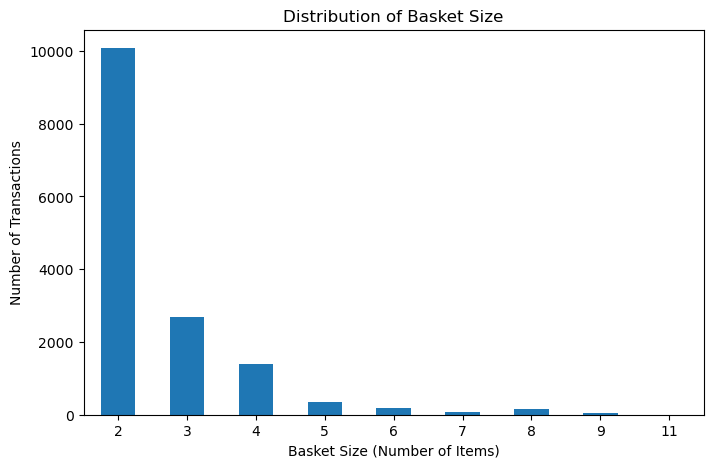

In [32]:
plt.figure(figsize=(8,5))

basket_distribution.plot(kind="bar")

plt.title("Distribution of Basket Size")
plt.xlabel("Basket Size (Number of Items)")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)

plt.show()

# MONTHLY TRANSACTION ANALYSIS

In [33]:
monthly_transaction = (
    df.groupby("Month")["Transaction_ID"]
      .nunique()
      .reset_index(name="Total_Transaction")
)

monthly_transaction

,Month,Total_Transaction
0,April,1244
1,August,1330
2,December,1196
3,February,1169
4,January,1287
5,July,1258
6,June,1253
7,March,1181
8,May,1328
9,November,1251


In [34]:
month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

monthly_transaction["Month"] = pd.Categorical(
    monthly_transaction["Month"],
    categories=month_order,
    ordered=True
)

monthly_transaction = monthly_transaction.sort_values("Month")

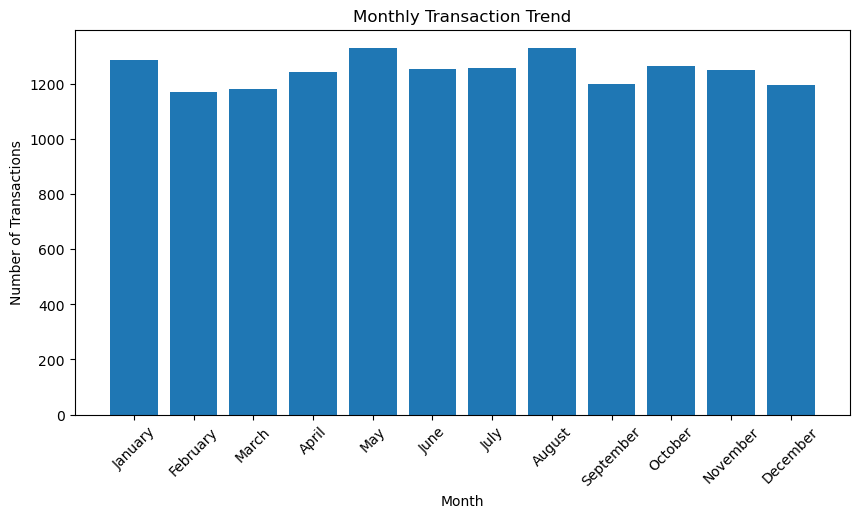

In [35]:
plt.figure(figsize=(10,5))

plt.bar(
    monthly_transaction["Month"],
    monthly_transaction["Total_Transaction"]
)

plt.title("Monthly Transaction Trend")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.show()

In [39]:
monthly_basket = (
    df.groupby("Month")["Basket_Size"]
      .mean()
      .reset_index(name="Average_Basket_Size")
)
print (monthly_basket)

        Month  Average_Basket_Size
0       April             3.126994
1      August             3.189359
2    December             2.923563
3    February             3.003337
4     January             3.043321
5        July             3.150303
6        June             3.073529
7       March             3.157676
8         May             3.053404
9    November             3.093423
10    October             3.042318
11  September             2.988231


# DAY TRANSACTION ANALYSIS

In [36]:
daily_transaction = (
    df.groupby("Day_Name")["Transaction_ID"]
      .nunique()
      .reset_index(name="Total_Transaction")
)

In [37]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

daily_transaction["Day_Name"] = pd.Categorical(
    daily_transaction["Day_Name"],
    categories=day_order,
    ordered=True
)

daily_transaction = daily_transaction.sort_values("Day_Name")

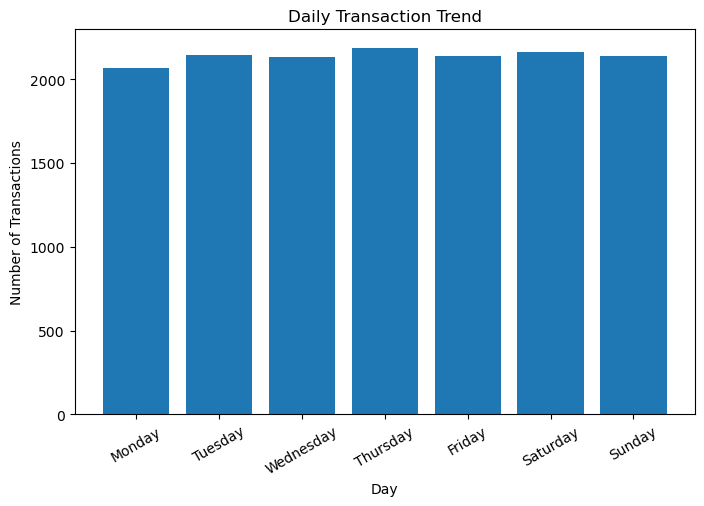

In [38]:
plt.figure(figsize=(8,5))

plt.bar(
    daily_transaction["Day_Name"],
    daily_transaction["Total_Transaction"]
)

plt.title("Daily Transaction Trend")
plt.xlabel("Day")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=30)

plt.show()

In [40]:
daily_basket = (
    df.groupby("Day_Name")["Basket_Size"]
      .mean()
      .reset_index(name="Average_Basket_Size")
)
print(daily_basket)

    Day_Name  Average_Basket_Size
0     Friday             3.126214
1     Monday             3.078781
2   Saturday             3.028463
3     Sunday             3.062929
4   Thursday             3.038434
5    Tuesday             3.058294
6  Wednesday             3.116145


# MARKET BASKET ANALYSIS

- ONE-HOT ENCODING

In [44]:
!pip install mlxtend --no-deps

  Using cached mlxtend-0.25.0-py3-none-any.whl.metadata (7.4 kB)
Using cached mlxtend-0.25.0-py3-none-any.whl (1.4 MB)


In [46]:
from mlxtend.preprocessing import TransactionEncoder

In [48]:
te = TransactionEncoder()

te_array = te.fit(basket["itemDescription"]).transform(basket["itemDescription"])

basket_encoded = pd.DataFrame(
    te_array,
    columns=te.columns_
)

In [49]:
basket_encoded.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [50]:
basket_encoded.shape

(14963, 167)

- FREQUENT ITEMSETS (APRIORI)

In [51]:
# Menentukan min support

# Total transaksi
n = basket_encoded.shape[0]

# Frekuensi setiap produk
item_counts = basket_encoded.sum(axis=0)

# Statistik frekuensi produk
max_freq = item_counts.max()
most_frequent_item = item_counts.idxmax()

mean_freq = item_counts.mean()
median_freq = item_counts.median()

print(f"Total Transactions : {n}")
print(f"Number of Products : {basket_encoded.shape[1]}")
print()

print(f"Most Frequent Item : {most_frequent_item}")
print(f"Maximum Support    : {max_freq/n:.4f}")

print(f"Mean Support       : {mean_freq/n:.4f}")
print(f"Median Support     : {median_freq/n:.4f}")

Total Transactions : 14963
Number of Products : 167

Most Frequent Item : whole milk
Maximum Support    : 0.1579
Mean Support       : 0.0152
Median Support     : 0.0057


In [97]:
from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(
    basket_encoded,
    min_support=0.01,
    use_colnames=True
)

frequent_itemsets = frequent_itemsets.sort_values(
    by="support",
    ascending=False
)

In [61]:
# Top Frequent 1-itemsets
frequent_itemsets[
    frequent_itemsets["itemsets"].apply(len) == 1
].sort_values("support", ascending=False).head(10)

,support,itemsets
62,0.157923,(whole milk)
40,0.122101,(other vegetables)
46,0.110005,(rolls/buns)
52,0.097106,(soda)
63,0.085879,(yogurt)
47,0.069572,(root vegetables)
57,0.067767,(tropical fruit)
5,0.060683,(bottled water)
49,0.060349,(sausage)
15,0.053131,(citrus fruit)


In [66]:
# Top Frequent 2-itemsets
frequent_itemsets[
    frequent_itemsets["itemsets"].apply(len) == 2
].sort_values("support", ascending=False).head()

,support,itemsets
65,0.014837,"(other vegetables, whole milk)"
66,0.013968,"(rolls/buns, whole milk)"
67,0.011629,"(soda, whole milk)"
68,0.011161,"(yogurt, whole milk)"
64,0.010559,"(other vegetables, rolls/buns)"


In [67]:
# Top Frequent 3-itemsets
frequent_itemsets[
    frequent_itemsets["itemsets"].apply(len) >= 3
].sort_values("support", ascending=False).head(10)

,support,itemsets


# ASSOCIATION RULES

In [79]:
# Menghitung treshold
from mlxtend.frequent_patterns import association_rules
import pandas as pd

thresholds = [0.01, 0.03, 0.05, 0.07, 0.10, 0.12, 0.15, 0.20]

result = []

for t in thresholds:
    rules_mba = association_rules(
        frequent_itemsets,
        metric="confidence",
        min_threshold=t
    )

    result.append({
        "Confidence_Threshold": t,
        "Number_of_Rules": len(rules_mba)
    })

threshold_analysis = pd.DataFrame(result)

threshold_analysis

,Confidence_Threshold,Number_of_Rules
0,0.01,10
1,0.03,10
2,0.05,10
3,0.07,10
4,0.10,4
5,0.12,3
6,0.15,0
7,0.20,0


In [95]:
# Menghitung confidence
from mlxtend.frequent_patterns import association_rules

rules_mba = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.07
)

In [81]:
rules_mba = rules_mba[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
].sort_values(
    by="lift",
    ascending=False
)

rules_mba

,antecedents,consequents,support,confidence,lift
6,(yogurt),(whole milk),0.011161,0.129961,0.822940
7,(whole milk),(yogurt),0.011161,0.070673,0.822940
2,(rolls/buns),(whole milk),0.013968,0.126974,0.804028
3,(whole milk),(rolls/buns),0.013968,0.088447,0.804028
8,(other vegetables),(rolls/buns),0.010559,0.086481,0.786154
9,(rolls/buns),(other vegetables),0.010559,0.095990,0.786154
0,(other vegetables),(whole milk),0.014837,0.121511,0.769430
1,(whole milk),(other vegetables),0.014837,0.093948,0.769430
4,(soda),(whole milk),0.011629,0.119752,0.758296
5,(whole milk),(soda),0.011629,0.073635,0.758296


In [82]:
rules_mba["antecedents"] = rules_mba["antecedents"].apply(
    lambda x: ", ".join(list(x))
)

rules_mba["consequents"] = rules_mba["consequents"].apply(
    lambda x: ", ".join(list(x))
)

In [83]:
rules_mba = rules_mba.reset_index(drop=True)

rules_mba.insert(
    0,
    "Rank",
    range(1, len(rules_mba)+1)
)

# SIMPAN HASIL RULES_MBA KE CSV

In [85]:
rules_mba.to_excel(
    "rules_mba.xlsx",
    index=False
)

print("Association Rules berhasil disimpan!")

Association Rules berhasil disimpan!


In [96]:
frequent_itemsets.to_excel(
    "frequent_itemsets.xlsx",
    index=False
)

print("frequent_itemsets berhasil disimpan!")

frequent_itemsets berhasil disimpan!
